# P10 — Neurons & Neural Networks from scratch  *(wire tiny decisions together and a brain appears)*

> **The story so far.** Through all of Part 1 the mind reasoned with single reflexes — one line, one
> rule, one nearest neighbour. Powerful, but flat: no single reflex can think a curved thought. Now
> Part 2 begins, and with it the most important moment in the whole story — **a brain forms.** Not
> from anything new, but from something old, repeated. One neuron is just the logistic unit you
> already built in P07: a weighted sum, then a squash. Wire many of them in layers, let each layer's
> answers become the next layer's questions, and something the parts never had appears between them —
> the ability to bend a straight line into any shape at all.

A real brain is billions of tiny yes/no cells whose only magic is in *how they're connected*. Our
mind's brain is the same idea in miniature: `z = w·x + b` then `f(z)`, stacked. The one ingredient
that makes the stack more than the sum of its lines is a **nonlinearity** between layers — without
it, ten layers collapse back into one. This notebook builds the **forward pass** of a 2-layer
network by hand, and proves *why* that nonlinearity matters using XOR — the deceptively simple
problem that stalled the field for a generation. Training the brain (backpropagation) is the flash of
learning in [P11](P11_Backpropagation.ipynb); here we get its architecture and shapes rock-solid.

## B1 — One neuron, recapped and generalised

Picture one brain cell deciding whether to fire: it gathers signals from everything wired into it,
weighs each by how much it trusts that connection, adds them up, and fires if the total crosses a
threshold. That is the entire neuron — and the mind already owns it from P07. Here we just generalise
"one cell" to "a whole layer of cells listening to the same inputs."

A **neuron** takes inputs `x`, computes a weighted sum plus bias, and applies an **activation**:
```
z = w·x + b           (the linear part — dot product from P01)
a = f(z)              (the activation — sigmoid, ReLU, tanh…)
```
A **layer** is several neurons sharing the same inputs. Stacking their weight-vectors as rows of a
matrix `W`, the whole layer is one matrix multiply (P01, B3):
```
z = W x + b           W is (n_neurons × n_inputs),  output z is (n_neurons,)
a = f(z)              activation applied element-wise
```
This is *exactly* `nn.Linear` followed by an activation. Same operation, many neurons at once.

In [1]:
import numpy as np
def relu(z):    return np.maximum(0, z)
def sigmoid(z): return 1/(1+np.exp(-z))

x = np.array([1.0, 2.0])                 # 2 inputs
W = np.array([[0.5, -1.0],               # layer of 3 neurons, each sees 2 inputs
              [1.0,  0.0],
              [-0.5, 0.5]])              # (3, 2)
b = np.array([0.0, 1.0, -1.0])

z = W @ x + b                            # one matmul = the whole layer's pre-activations
print("z = W x + b   :", z, " (3 neurons' weighted sums)")
print("relu(z)       :", relu(z))
print("sigmoid(z)    :", np.round(sigmoid(z), 3))
print("shapes: W", W.shape, " x", x.shape, " -> z", z.shape)

z = W x + b   : [-1.5  2.  -0.5]  (3 neurons' weighted sums)
relu(z)       : [0. 2. 0.]
sigmoid(z)    : [0.182 0.881 0.378]
shapes: W (3, 2)  x (2,)  -> z (3,)


## B2 — Activations: the menu, and why we need one at all

Why can't the mind just stack plain weighted sums and call it deep? Because of a quiet catastrophe:
a sum of sums is still a sum. Fold a piece of paper a hundred times *without ever creasing it* and
it's still flat. The crease — the bend — is the activation. It's the one nonlinear move that lets
depth actually buy the brain new shapes of thought.

Notebook 00 (B5) proved it: stack linear layers with no nonlinearity and they **collapse** into a
single linear layer — depth buys nothing. The activation between layers is what lets a deep network
bend straight lines into curves. The common choices:

| Activation | Formula | Range | Used for |
|------------|---------|-------|----------|
| Sigmoid | `1/(1+e⁻ᶻ)` | (0,1) | probabilities / old hidden layers |
| Tanh | `(eᶻ−e⁻ᶻ)/(eᶻ+e⁻ᶻ)` | (−1,1) | zero-centred hidden layers |
| ReLU | `max(0, z)` | [0,∞) | the modern default for hidden layers |

**Worked example by hand.**
```
z = −2 :  sigmoid 0.119,  tanh −0.964,  relu 0
z =  0 :  sigmoid 0.500,  tanh  0.000,  relu 0
z =  3 :  sigmoid 0.953,  tanh  0.995,  relu 3
```
ReLU wins in practice because it's cheap and its gradient doesn't vanish for positive inputs (P13).

z=-2 : sigmoid 0.119 tanh -0.964 relu 0
z= 3 : sigmoid 0.953 tanh 0.995 relu 3


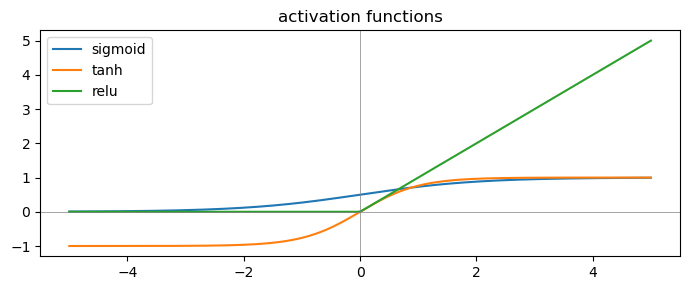

In [2]:
import numpy as np, matplotlib.pyplot as plt
z = np.linspace(-5, 5, 200)
acts = {"sigmoid": 1/(1+np.exp(-z)), "tanh": np.tanh(z), "relu": np.maximum(0,z)}
for name, val in acts.items():
    for zz in [-2,0,3]:
        pass
print("z=-2 : sigmoid %.3f tanh %.3f relu %.0f" % (1/(1+np.exp(2)), np.tanh(-2), max(0,-2)))
print("z= 3 : sigmoid %.3f tanh %.3f relu %.0f" % (1/(1+np.exp(-3)), np.tanh(3), max(0,3)))
plt.figure(figsize=(7,3))
for name,val in acts.items(): plt.plot(z,val,label=name)
plt.axhline(0,c="gray",lw=.5); plt.axvline(0,c="gray",lw=.5); plt.legend(); plt.title("activation functions")
plt.tight_layout(); plt.show()

## B3 — The XOR problem: proof that one layer is not enough

Here is the puzzle that humbled a generation of researchers and nearly ended neural networks before
they began. It looks trivial — a light switch that's on when *exactly one* of two switches is flipped
— yet a single straight-line mind cannot solve it, no matter how hard it tries. Watching the mind
fail this is the clearest possible proof of why it needs a hidden layer.

XOR (exclusive-or) outputs 1 when exactly one input is 1:
```
(0,0)->0   (0,1)->1   (1,0)->1   (1,1)->0
```
Plot those four points: the two 1s and the two 0s sit on opposite diagonals. **No straight line can
separate them** — so logistic regression (P07) is mathematically incapable of solving XOR. This
exact problem stalled neural-network research for years. The fix: a hidden layer with a
nonlinearity, which can carve a curved boundary. We confirm the failure, then the fix.

In [3]:
import numpy as np
from sklearn.linear_model import LogisticRegression
X = np.array([[0,0],[0,1],[1,0],[1,1]], float)
y = np.array([0,1,1,0])                          # XOR

acc = LogisticRegression().fit(X, y).score(X, y)
print("logistic regression accuracy on XOR:", acc, " (stuck at 0.5–0.75 — it CANNOT do it)")
print("reason: XOR's two classes are not separable by any single straight line.")

logistic regression accuracy on XOR: 0.5  (stuck at 0.5–0.75 — it CANNOT do it)
reason: XOR's two classes are not separable by any single straight line.


## B4 — A 2-layer network solves XOR (forward pass by hand)

Now give the mind one hidden layer — a private inner step between question and answer where it can
reshape the problem before deciding. Suddenly XOR is easy. We'll hand the network the right weights
(in P11 it will *discover* them itself) and trace a single input all the way through, every number by
hand, so you can watch the impossible become routine.

A hidden layer of 2 ReLU neurons gives the network enough flexibility. With these **hand-picked**
weights (training would discover them — that's P11), the network computes XOR exactly. Let's trace
the input `(1,1)` → expected output 0, every number by hand.
```
Hidden layer:  W1 = [[1, 1],     b1 = [0, -1]      h = relu(W1·x + b1)
                     [1, 1]]
Output layer:  W2 = [1, -2],     b2 = 0            y = W2·h + b2
```
For x = (1,1):
```
W1·x + b1 = [1·1+1·1+0 , 1·1+1·1−1] = [2, 1]
h = relu([2, 1]) = [2, 1]
y = 1·2 + (−2)·1 + 0 = 2 − 2 = 0     ✓  (XOR(1,1)=0)
```

In [4]:
import numpy as np
def relu(z): return np.maximum(0, z)

W1 = np.array([[1.0, 1.0],
               [1.0, 1.0]]); b1 = np.array([0.0, -1.0])
W2 = np.array([1.0, -2.0]);  b2 = 0.0

def net(x):
    h = relu(W1 @ x + b1)        # hidden layer
    return W2 @ h + b2           # output

X = np.array([[0,0],[0,1],[1,0],[1,1]], float)
print("hand check for x=(1,1): hidden [2,1] -> output 0\n")
for x in X:
    print(f"  x={x.astype(int)}  ->  net = {net(x):.1f}   (XOR target {int(x[0]) ^ int(x[1])})")
print("\nthe 2-layer net reproduces XOR exactly — the hidden nonlinearity made it possible.")

hand check for x=(1,1): hidden [2,1] -> output 0

  x=[0 0]  ->  net = 0.0   (XOR target 0)
  x=[0 1]  ->  net = 1.0   (XOR target 1)
  x=[1 0]  ->  net = 1.0   (XOR target 1)
  x=[1 1]  ->  net = 0.0   (XOR target 0)

the 2-layer net reproduces XOR exactly — the hidden nonlinearity made it possible.


## B5 — A general multi-layer network (a forward pass with random weights)

Everything bigger is just this one move on repeat. A network that recognises faces and a network that
writes poetry share the exact same skeleton as our XOR toy — only wider and deeper. Once you can read
one forward pass, you can read them all; the rest is scale.

Real networks are this same pattern repeated: `x → Linear → activation → Linear → activation → …
→ output`. Here's a general 3-layer forward pass on a batch of inputs, so you see how shapes flow.
This is the entire "inference" path — given weights, produce outputs. (How to *find* good weights
is backprop, next.)

In [5]:
import numpy as np
rng = np.random.default_rng(0)
def relu(z): return np.maximum(0, z)

# layer sizes: 3 inputs -> 4 hidden -> 4 hidden -> 2 outputs
sizes = [3, 4, 4, 2]
Ws = [rng.normal(0, 0.5, (sizes[i+1], sizes[i])) for i in range(len(sizes)-1)]
bs = [np.zeros(sizes[i+1]) for i in range(len(sizes)-1)]

def forward(x):
    a = x
    for i, (W, b) in enumerate(zip(Ws, bs)):
        z = W @ a + b
        a = relu(z) if i < len(Ws)-1 else z      # no activation on the final layer
    return a

X = rng.normal(size=(5, 3))                       # batch of 5 inputs
print("network shape:", " -> ".join(map(str, sizes)))
for i, x in enumerate(X):
    print(f"  input {i} (3 nums) -> output {np.round(forward(x),3)} (2 nums)")
print("\nevery layer = matmul + bias + activation. That's the whole forward pass.")

network shape: 3 -> 4 -> 4 -> 2
  input 0 (3 nums) -> output [-0.066  0.062] (2 nums)
  input 1 (3 nums) -> output [-0.251  0.105] (2 nums)
  input 2 (3 nums) -> output [0.023 0.056] (2 nums)
  input 3 (3 nums) -> output [-0.024  0.041] (2 nums)
  input 4 (3 nums) -> output [0.034 0.083] (2 nums)

every layer = matmul + bias + activation. That's the whole forward pass.


## Recap — architecture of a neural network

| Piece | Formula | Notebook |
|-------|---------|----------|
| Neuron | `a = f(w·x + b)` | = logistic unit (P07) |
| Layer | `a = f(W x + b)` | one matmul (P01) |
| Network | layers stacked, activation between | this notebook |
| Why nonlinearity | else layers collapse to one | NB00 B5, XOR here |
| Forward pass | input → … → output | B5 |

## Common mistakes
1. **Forgetting the activation between layers** → the whole net collapses to linear (can't solve XOR).
2. **Putting an activation on the final regression output** → squashes your range. Usually leave the last layer linear (or softmax for classification).
3. **Shape mismatches.** `W` for a layer is `(out_features × in_features)`; print shapes when in doubt (P00).
4. **Expecting a single neuron to do XOR-like tasks.** It can only draw a line; you need a hidden layer.
5. **Confusing "deep" with "good".** Depth needs the nonlinearity *and* training (P11) to pay off.

## Exercises (do them in new code cells)
1. Hand-compute the XOR net's output for `x=(0,1)`. Does it give 1? Trace the hidden layer.
2. Add a third input to the B1 neuron layer (make `W` shape `(3,3)`). What changes in the shapes?
3. Replace ReLU with sigmoid in the B4 XOR net (keep the same weights). Does it still output ~0/1? Why might it differ?
4. In B5, change `sizes` to `[3, 8, 2]`. How many weight matrices now? What are their shapes?
5. Why does leaving the final layer *without* an activation make sense for predicting an unbounded number?

---

**The brain now exists — but it's frozen.** We hand-picked its weights; left to itself it knows
nothing. The miracle is still missing: the ability to learn its own connections from nothing but
examples and mistakes. Next comes the flash of learning:
[P11 — Backpropagation, fully by hand](P11_Backpropagation.ipynb) — the algorithm that *finds* all
these weights, derived and hand-computed gradient by gradient. This is the most important notebook in
Part 2; it is the moment the mind truly wakes up.